In [1]:
import pandas as pd 
import numpy as np

In [4]:
google_data = pd.read_csv('google_data_cleaned.csv')

In [6]:
google_data.head(20)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [7]:
google_data['Category'].nunique()

33

In [8]:
google_data['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

In [11]:
category_counts = google_data['Category'].value_counts()

In [12]:
category_counts

Category
FAMILY                 1969
GAME                   1144
TOOLS                   841
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         390
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     230
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  82
EVENTS                   64
ART_AND_DESIGN           64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64

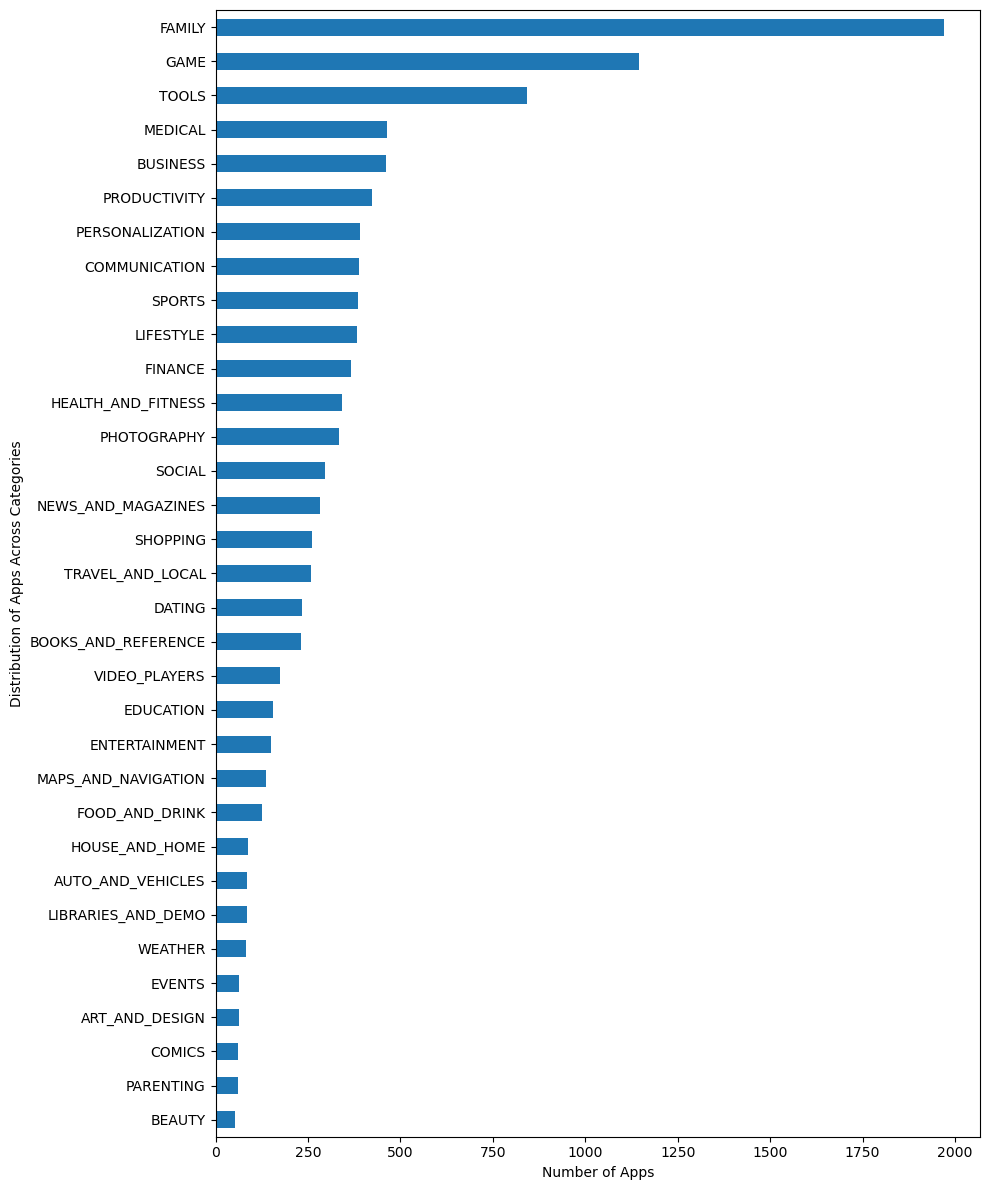

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 12))
category_counts.sort_values().plot(kind='barh')
plt.xlabel('Number of Apps')
plt.ylabel('Distribution of Apps Across Categories')
plt.tight_layout()
plt.show()



In [17]:
category_summary= google_data.groupby('Category').agg(
    app_count=('App', 'count'),
    avg_rating=('Rating', 'mean'),
    total_installs=('Installs', 'sum')).sort_values('app_count', ascending=False)
               

In [18]:
category_summary.head(10)

,app_count,avg_rating,total_installs
Category,,,
FAMILY,1969,4.204571,"50,000,000+10,000,000+100,000,000+1,000,000+5,..."
GAME,1144,4.286888,"100,000,000+1,000,000,000+500,000,000+10,000,0..."
TOOLS,841,4.079667,"10,000,000+1,000,000,000+500,000,000+10,000,00..."
MEDICAL,463,4.216199,"100,000+10,000+10,000+10,000+10,000+10,000+5,0..."
BUSINESS,460,4.182391,"10,000,000+50,000,000+10,000,000+5,000,000+1,0..."
PRODUCTIVITY,424,4.226651,"500,000,000+10,000,000+100,000,000+10,000,000+..."
PERSONALIZATION,390,4.328205,"50,000,000+1,000,000+100,000,000+5,000,000+100..."
COMMUNICATION,387,4.180103,"1,000,000,000+1,000,000,000+10,000,000+1,000,0..."
SPORTS,384,4.236458,"10,000,000+100,000+10,000,000+5,000,000+50,000..."


In [21]:
google_data['Installs'] = google_data['Installs'].str.replace(',', '').str.replace('+', '').astype(int)

In [22]:
google_data['Installs'].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

In [25]:
category_summary = google_data.groupby('Category').agg(
    app_count=('App', 'count'),
    avg_rating=('Rating', 'mean'),
    total_installs=('Installs', 'sum')).sort_values('app_count', ascending=False)

In [27]:
category_summary.head(10)

,app_count,avg_rating,total_installs
Category,,,
FAMILY,1969,4.204571,10258203405
GAME,1144,4.286888,35086024415
TOOLS,841,4.079667,11452271905
MEDICAL,463,4.216199,53257437
BUSINESS,460,4.182391,1001914865
PRODUCTIVITY,424,4.226651,14176091369
PERSONALIZATION,390,4.328205,2325483782
COMMUNICATION,387,4.180103,32647276251
SPORTS,384,4.236458,1751174498


In [ ]:
**By  totoal insalls(actual demand):**
GAME leads with ~35.1B total installs, aligning with its high app count.
COMMUNICATION is the most notable outlier: with only 387 apps (far fewer than
FAMILY's 1,969), it generates ~32.6B intalls -- nearly matching GAME -showing 
that a small number of communacation apps (e.g., messing platforms) reach an
enomous user base. FAMILY, depite having the most apps overall (1,969), TOTLAS
ONLY ~10.3B insalls, roughly a third of GAMESnand less than COMMUNICATION's
MEDICAL shows the opposite pattern: 463 apps but just ~53M installs, indicating
a saturated category with camparatively low demand per app.
This confirms that app count is a poor proxy for actual demand - categories like 
COMMUNICATION and PRODUCTIVITY punch well above their weight in installs relative
to how many appps theyu contain, while categories like FAMILY and MEDICAL are 
crowded but don't convert that volume into proportional downloads
